In [1]:
# Getting all the Data

import pandas as pd
import numpy as np

df = pd.read_csv('df.csv')
firstpurchase_summ = pd.read_csv('firstpurchase_summ.csv')
cohort = pd.read_csv('cohort.csv')
churn = pd.read_csv('churn.csv')
customers_contr = pd.read_csv('customers_contr.csv')

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

In [2]:
df['TransactionType'] = np.where(df['Quantity'] < 0, 'Refund', 'Purchase')
df.drop(np.where(df['Quantity'] == 0)[0], inplace = True)
df.drop(columns = 'Unnamed: 0', inplace = True)

df['CustomerID'] = df['CustomerID'].astype(str)
df['StockCode'] = df['StockCode'].astype(str).str.replace('.', '')

df.sample(4)

,InvoiceDate,InvoiceNo,CustomerID,StockCode,Country,Description,Quantity,Price,Revenue,DayOfWeek,Month,RevenueLag_1Day,PurchaseID,UnitPrice,AvgMonthlyProductRevenue,AvgMonthlyUnitPrice,AvgMonthlyQuantitySold,Cohort,OrderMonth,FirstPurchaseDate,IsFirstPurchase,UnitCost,TotalCost,GrossProfit,GrossMargin,TransactionType
44586,2011-05-12,553014,1345100,180070,United Kingdom,ESSENTIAL BALM 35g TIN IN ENVELOPE,2,0.18,0.36,4,5,5.0,13451-18007,0.09,2.17,0.13,12.0,2011-05,2011-05,2011-05-12,True,0.009,0.018,0.342,95.0,Purchase
6703,2011-03-25,547713,1645800,223860,United Kingdom,JUMBO BAG PINK POLKADOT,10,1.95,19.50,5,3,19.5,16458-22386,0.20,47.47,0.97,26.0,2011-03,2011-03,2011-03-25,True,0.000,0.000,19.500,100.0,Purchase
18579,2011-04-08,549360,1703500,226990,United Kingdom,ROSES REGENCY TEACUP AND SAUCER,6,2.95,17.70,5,4,17.7,17035-22699,0.49,18.76,1.41,6.0,2011-04,2011-04,2011-04-08,True,0.000,0.000,17.700,100.0,Purchase
1958,2011-03-20,547066,1292100,224170,United Kingdom,PACK OF 60 SPACEBOY CAKE CASES,24,0.55,13.20,7,3,13.2,12921-22417,0.02,12.79,0.40,23.0,2011-03,2011-03,2011-03-20,True,0.000,0.000,13.200,100.0,Purchase


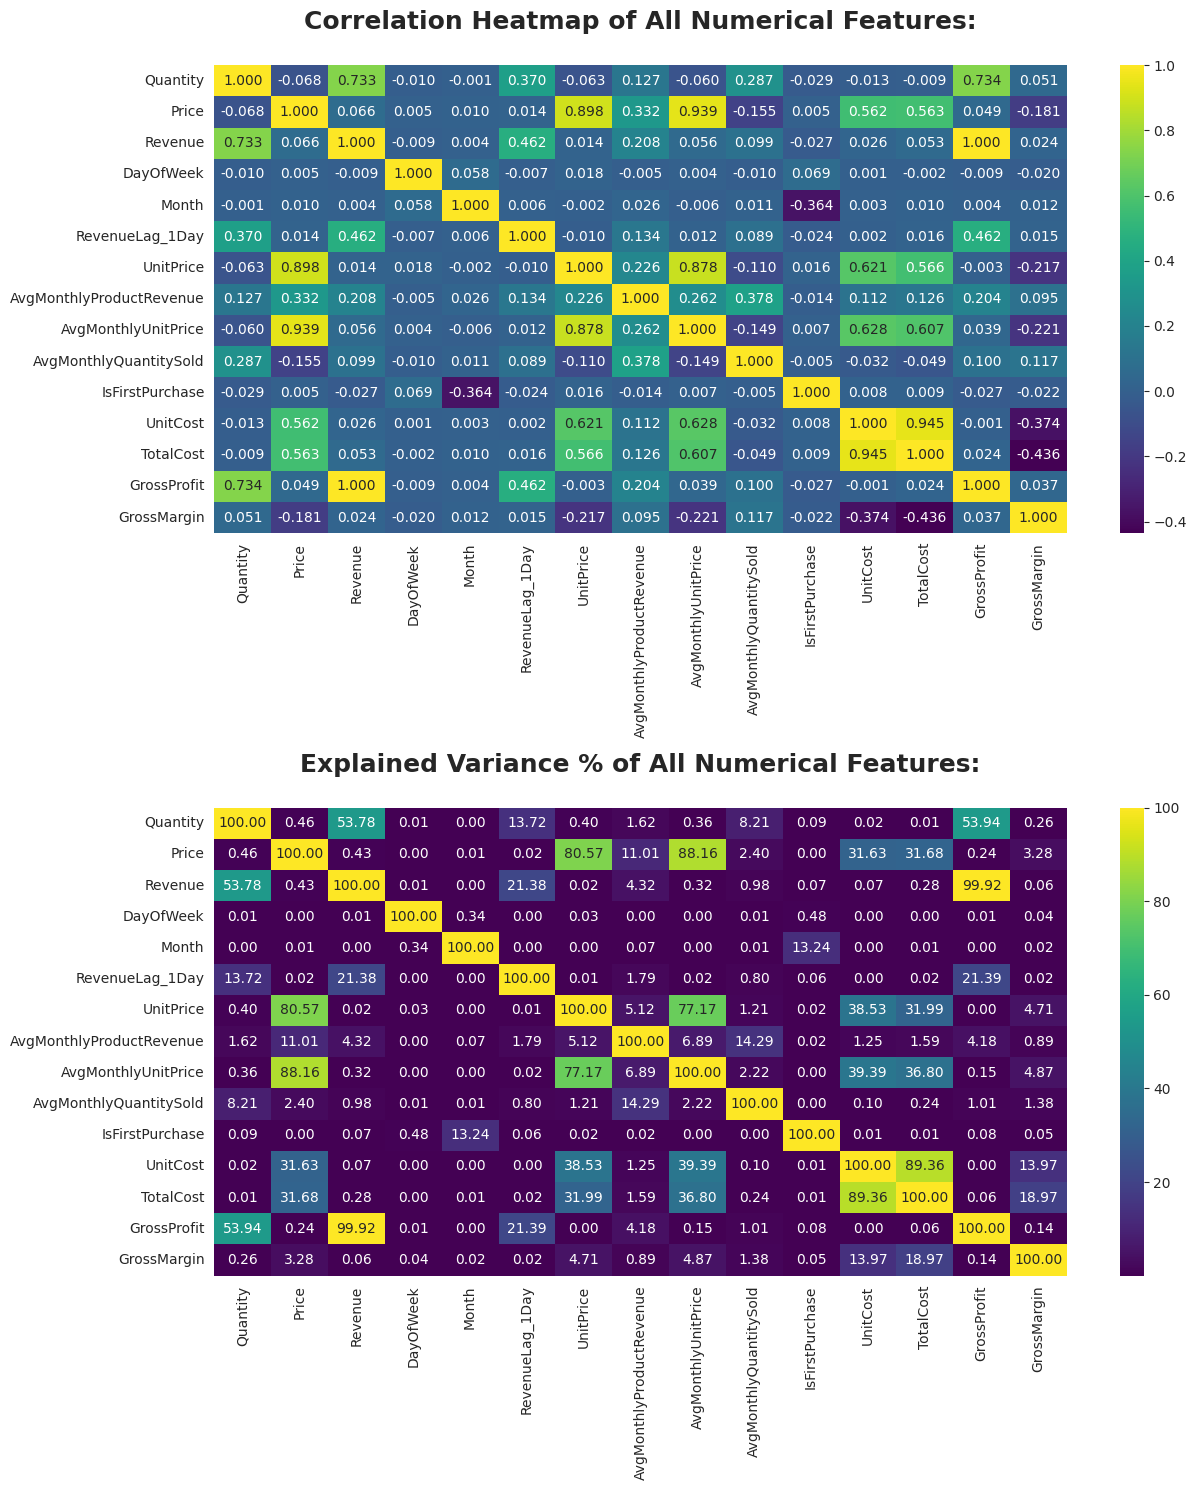

In [3]:
# Insightful Heatmaps for Numerical Features

fig, axes = plt.subplots(2, 1, figsize = (13, 15)) # Dimensions for Both Plots Within One Space

# First Plot: Correlation Heatmap
sns.heatmap(df.corr(numeric_only = True),
            annot = True,
            fmt = '.3f',
            cmap = 'viridis',
            ax = axes[0]) # Assign to the first axis
axes[0].set_title("Correlation Heatmap of All Numerical Features:\n",
                  fontweight = 'bold',
                  fontsize = 18)

# Second Plot: Explained Variance Heatmap
sns.heatmap((df.corr(numeric_only = True)**2)*100,
            annot = True,
            fmt = '.2f',
            cmap = 'viridis',
            ax = axes[1]) # Assign to the second axis
axes[1].set_title("Explained Variance % of All Numerical Features:\n",
                  fontweight = 'bold',
                  fontsize = 18)

plt.tight_layout() # Automatically adjusts subplot parameters for a tight layout
plt.show()

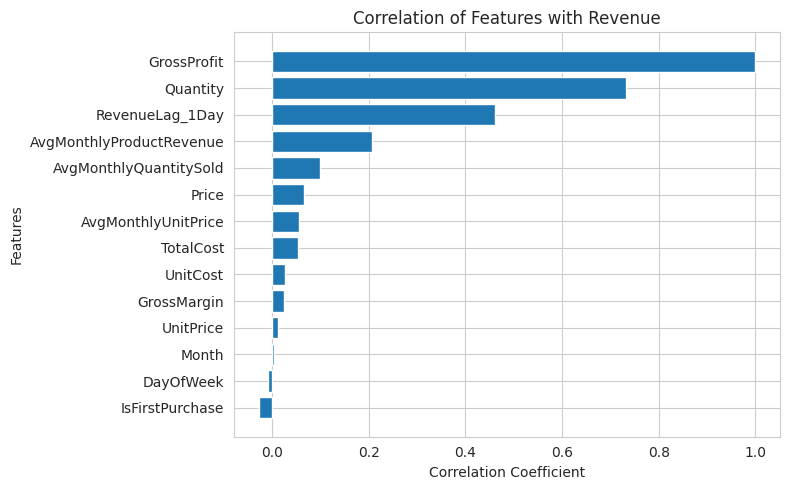

In [4]:
# Core Feature: Revenue
# Let's see how others Correlate with it

corr_rev = df.corr(numeric_only = True)['Revenue'].sort_values(ascending = True)
plt.figure(figsize = (8, 5))
plt.barh(y = corr_rev.index[:-1], # Removing the Correlation of "Revenue" with Revenue itself
         width = corr_rev.values[:-1]) # Removed 'annot = True'
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.title('Correlation of Features with Revenue')
plt.tight_layout()
plt.show()

In [5]:
# Which Day of the Week boasts the Highest Relative Core Measures Compared to the Average?

df2 = df.copy()
df2 = df2.groupby('DayOfWeek')[['Revenue', 'Quantity', 'Price', 'TotalCost', 'GrossProfit']].sum().reset_index()
df3 = df.groupby('DayOfWeek')['GrossMargin'].mean().reset_index()

df2 = df2.merge(df3, on = 'DayOfWeek')

df2['DayOfWeek'] = df2['DayOfWeek'].astype(str).str.replace('7', '6')

df2['RelativeAverageRevenueDifference'] = (((df2['Revenue'] - df2['Revenue'].mean()) / df2['Revenue'].mean()) * 100).round(2)
df2['RelativeQuantitySoldDifference'] = (((df2['Quantity'] - df2['Quantity'].mean()) / df2['Quantity'].mean()) * 100).round(2)
df2['RelativeProductMarginDifference'] = ((((df2['Price'] - df2['TotalCost']) - (df2['Price'] - df2['TotalCost']).mean()) / (df2['Price'] - df2['TotalCost']).mean()) * 100).round(2)
df2['RelativeGrossProfitDifference'] = (((df2['GrossProfit'] - df2['GrossProfit'].mean()) / df2['GrossProfit'].mean()) * 100).round(2)
df2['RelativeGrossMarginDifference'] = (df2['GrossMargin'] - df2['GrossMargin'].mean()).round(2)

df2

,DayOfWeek,Revenue,Quantity,Price,TotalCost,GrossProfit,GrossMargin,RelativeAverageRevenueDifference,RelativeQuantitySoldDifference,RelativeProductMarginDifference,RelativeGrossProfitDifference,RelativeGrossMarginDifference
0,1,102541.99,59925,19178.43,2147.985,100394.005,97.146070,-26.71,-30.84,-15.26,-26.75,0.08
1,2,152726.90,94889,24522.67,3180.474,149546.426,97.216946,9.16,9.50,6.19,9.11,0.15
2,3,174291.73,119354,23749.01,3052.971,171238.759,97.131713,24.57,37.74,2.98,24.93,0.06
3,4,186197.21,109404,30982.16,4150.539,182046.671,97.207273,33.08,26.26,33.51,32.82,0.14
4,5,142834.53,86301,20778.57,2637.234,140197.296,97.171192,2.09,-0.41,-9.73,2.29,0.10
5,6,80902.80,50046,18481.60,1939.734,78963.066,96.527629,-42.18,-42.25,-17.69,-42.39,-0.54


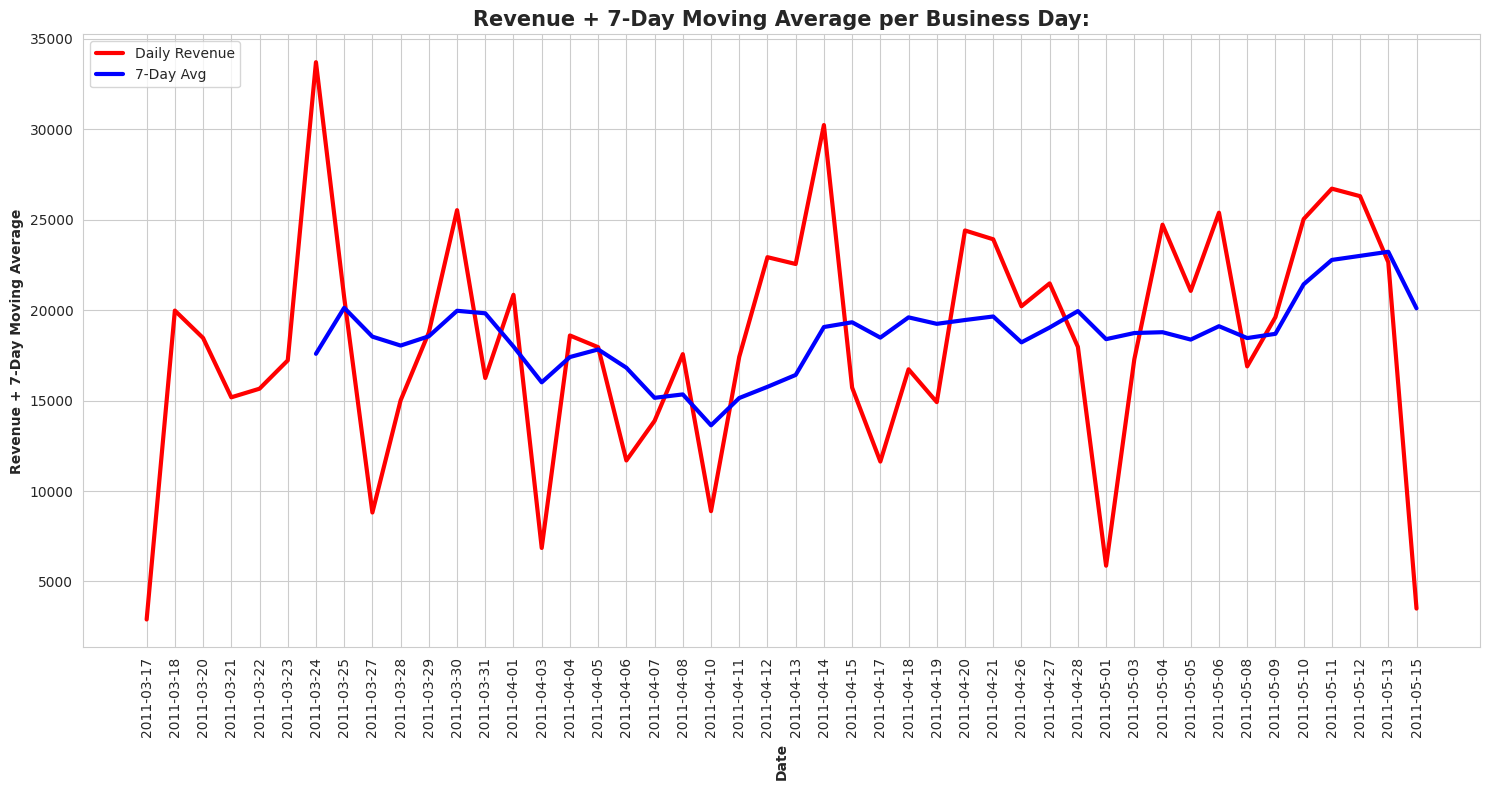

In [6]:
# Revenue Trend + Moving Average + Business Metrics (Gross Profit and Gross Margins), per Business Day

daily = df.groupby('InvoiceDate')['Revenue'].sum().reset_index()
daily['MA7'] = daily['Revenue'].rolling(7).mean() # 7-Day Moving Average of Revenue
costs_prices = df.groupby('InvoiceDate')[['TotalCost', 'Price']].sum().reset_index()
profits_margins_bydate = costs_prices.copy()
profits_margins_bydate['GrossProfit'] = (profits_margins_bydate['Price'] - profits_margins_bydate['TotalCost']).round(2)
profits_margins_bydate['GrossMargin'] = ((profits_margins_bydate['GrossProfit'] / profits_margins_bydate['Price'])*100).round(2)

plt.figure(figsize = (15, 8))

# Primary Y-Axis (ax1) Plot
plt.plot(daily['InvoiceDate'],
         daily['Revenue'],
         label = "Daily Revenue",
         linewidth = 3,
         color = 'red')
plt.plot(daily['InvoiceDate'],
         daily['MA7'],
         label = "7-Day Avg",
         linewidth = 3,
         color = 'blue')
plt.xlabel("Date", fontweight = 'bold', rotation = 90)
plt.xticks(rotation = 90)
plt.ylabel("Revenue + 7-Day Moving Average",fontweight = 'bold')

plt.title("Revenue + 7-Day Moving Average per Business Day:", fontweight = 'bold', fontsize = 15)

# Let's See Now
plt.tight_layout()
plt.legend(loc = 'upper left')
plt.show()

# Sample Insight: Revenue shows Volatility with Smoother underlying Growth Trends, indicating Seasonality or Campaign-driven Spikes.

<Figure size 1600x700 with 0 Axes>

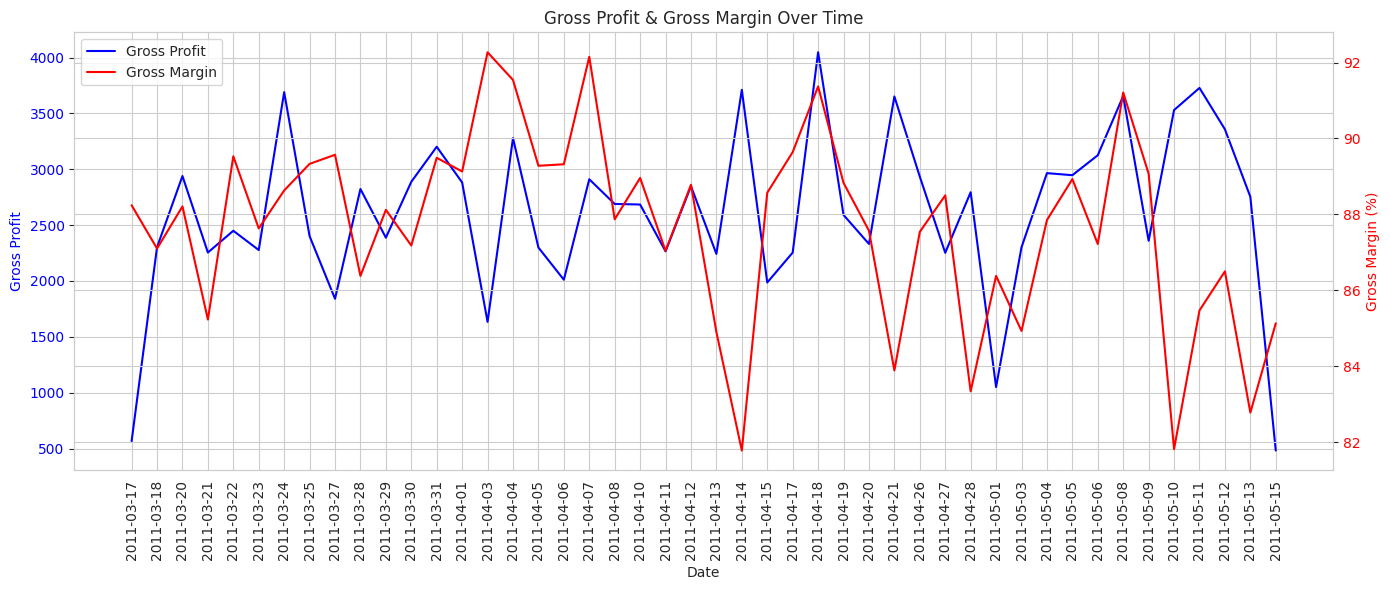

In [7]:
# Gross Profit + Gross Margin Visualizer with Secondary Y-Axis

plt.figure(figsize = (16, 7))

fig, ax1 = plt.subplots(figsize = (14, 6))

# Plot: Gross Profit on the Primary Y-Axis
sns.lineplot(x = profits_margins_bydate['InvoiceDate'],
             y = profits_margins_bydate['GrossProfit'],
             label = 'Gross Profit', color = 'blue', ax = ax1, legend = False)
ax1.set_xlabel('Date')
ax1.set_ylabel('Gross Profit', color = 'blue')
ax1.tick_params(axis = 'x', rotation = 90)
ax1.tick_params(axis = 'y', labelcolor = 'blue')

# Plot: Gross Margin on the Secondary Y-Axis
ax2 = ax1.twinx()
sns.lineplot(x = profits_margins_bydate['InvoiceDate'],
             y = profits_margins_bydate['GrossMargin'],
             label = 'Gross Margin', color = 'red', ax = ax2, legend = False)
ax2.set_ylabel('Gross Margin (%)', color = 'red')
ax2.tick_params(axis = 'y', labelcolor = 'red')

# One Singular Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc = 'upper left')

# Let's See
plt.title('Gross Profit & Gross Margin Over Time')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

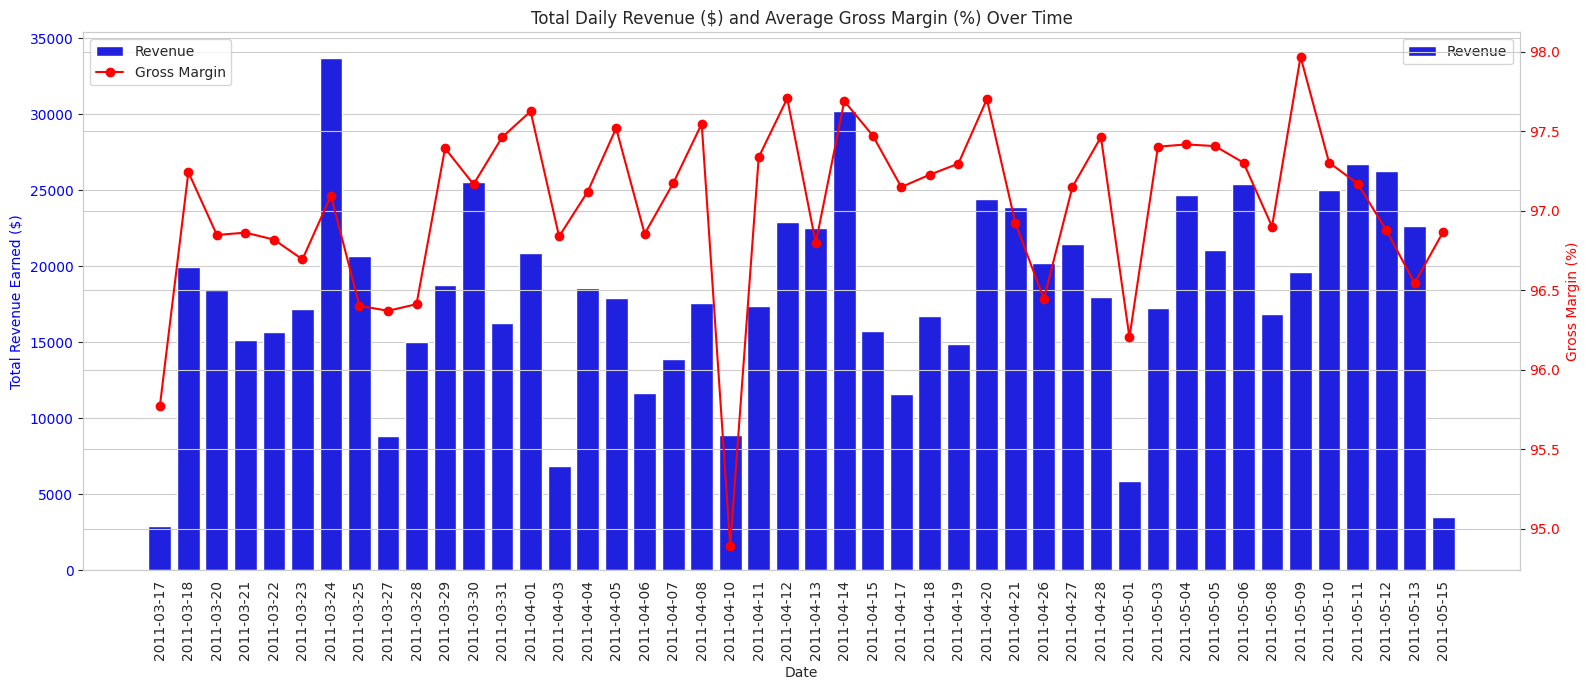

In [8]:
# Daily Breakdown: Analysis of Key Metrics

metrics = df.groupby('InvoiceDate').agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'CustomerID': 'nunique',
    'StockCode': 'nunique',
    'GrossMargin': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize = (16, 7))

# Plot Revenue on the primary y-axis (bar plot)
sns.barplot(x = metrics['InvoiceDate'], y = metrics['Revenue'], ax = ax1, color = 'blue', label = 'Revenue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Revenue Earned ($)', color = 'blue')
ax1.tick_params(axis = 'x', rotation = 90)
ax1.tick_params(axis = 'y', labelcolor = 'blue')

# Create a secondary y-axis for Gross Margin (line plot)
ax2 = ax1.twinx()
ax2.plot(metrics['InvoiceDate'], metrics['GrossMargin'], color = 'red', linestyle = '-', marker = 'o', label = 'Gross Margin')
ax2.set_ylabel('Gross Margin (%)', color = 'red')
ax2.tick_params(axis = 'y', labelcolor = 'red')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc = 'upper left')

plt.title('Total Daily Revenue ($) and Average Gross Margin (%) Over Time')
plt.tight_layout()
plt.show()

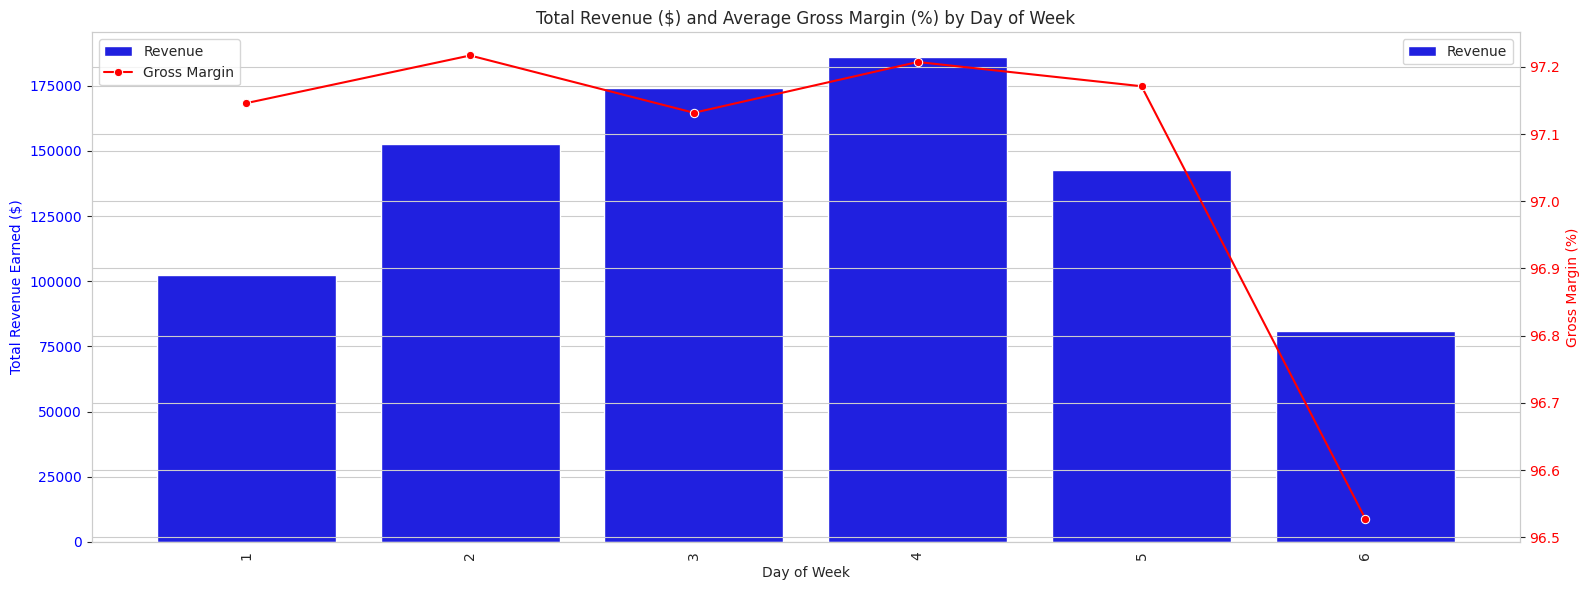

In [9]:
# Weekly Breakdown: Analysis of Key Metrics

metrics2 = df.groupby('DayOfWeek').agg({
    'Quantity': 'sum',
    'Revenue': 'sum',
    'CustomerID': 'nunique',
    'StockCode': 'nunique',
    'GrossMargin': 'mean'
}).reset_index()

metrics2['DayOfWeek'] = metrics2['DayOfWeek'].astype(str).str.replace('7', '6')

# The Store is Closed on one of the Days of the Weekend, hence no Data on it
# So, will Assume it's Sunday and will Replace the Value of '7' with '6' to Indicate Saturday

fig, ax1 = plt.subplots(figsize = (16, 6))

# Plot Revenue on the primary y-axis (bar plot)
sns.barplot(x = metrics2['DayOfWeek'], y = metrics2['Revenue'], ax = ax1, color = 'blue', label = 'Revenue')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Total Revenue Earned ($)', color = 'blue')
ax1.tick_params(axis = 'x', rotation = 90)
ax1.tick_params(axis = 'y', labelcolor = 'blue')

# Create a secondary y-axis for Gross Margin (line plot)
ax2 = ax1.twinx()
sns.lineplot(x = metrics2['DayOfWeek'], y = metrics2['GrossMargin'], ax = ax2, color = 'red', linestyle = '-', marker = 'o', label = 'Gross Margin')
ax2.set_ylabel('Gross Margin (%)', color = 'red')
ax2.tick_params(axis = 'y', labelcolor = 'red')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc = 'upper left')

plt.title('Total Revenue ($) and Average Gross Margin (%) by Day of Week')
plt.tight_layout()
plt.show()

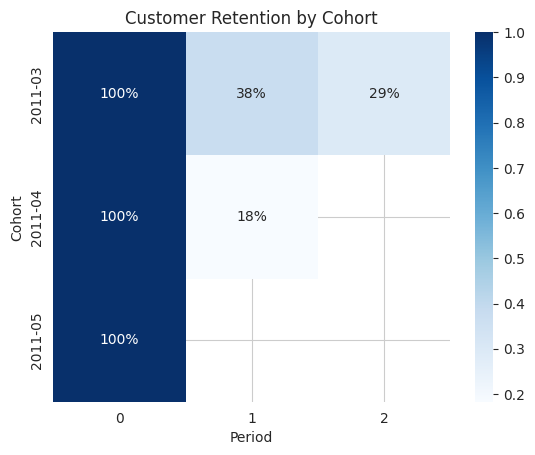

In [10]:
# Cohort Retention Heatmap

pivot = cohort.pivot(index = 'Cohort', columns = 'Period', values = 'CustomerID')
retention = pivot.divide(pivot[0], axis = 0)

plt.figure()
sns.heatmap(retention, annot = True, fmt = ".0%", cmap = "Blues")
plt.title("Customer Retention by Cohort")
plt.show()

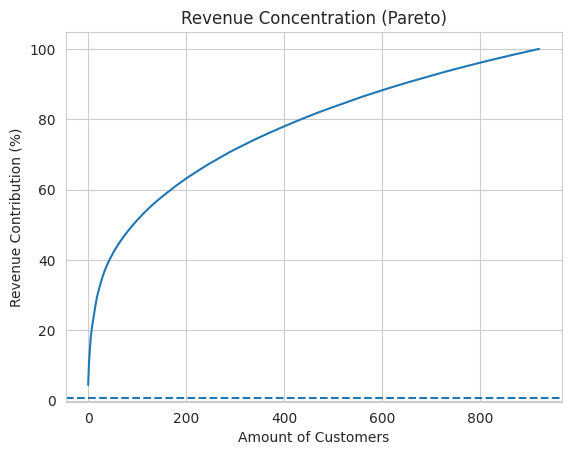

In [11]:
# Pareto Curve (Revenue Concentration)

plt.figure()
plt.plot(customers_contr['ContributionPct'].values)
plt.axhline(0.8, linestyle = '--')
plt.xlabel("Amount of Customers")
plt.ylabel("Revenue Contribution (%)")
plt.title("Revenue Concentration (Pareto)")
plt.show()

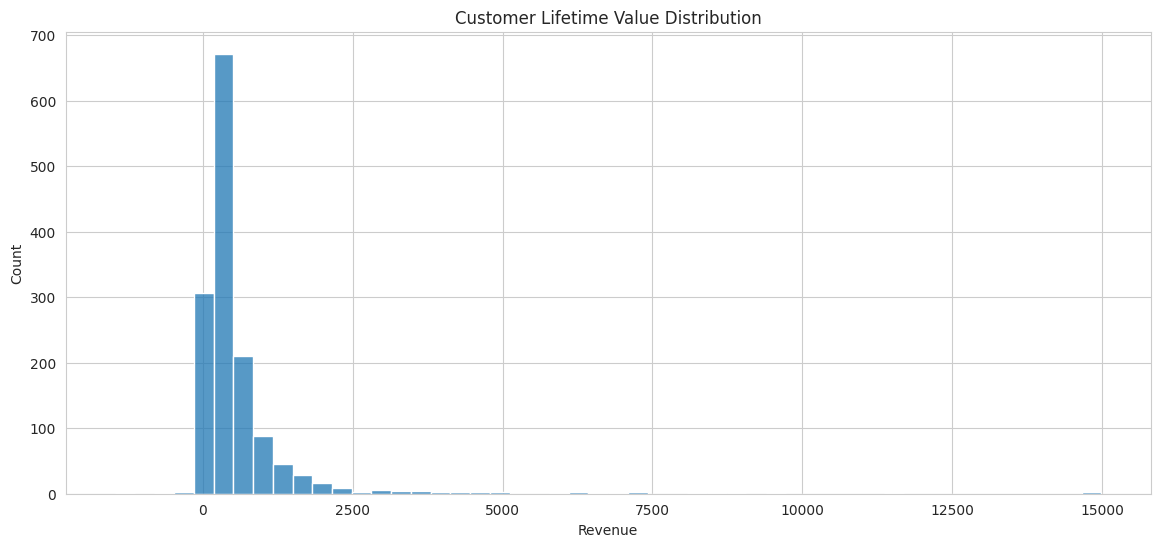

In [12]:
# LTV Distribution

ltv = df.groupby('CustomerID')['Revenue'].sum()

plt.figure(figsize = (14, 6))
sns.histplot(ltv, bins = 50)
plt.title("Customer Lifetime Value Distribution")
plt.show()

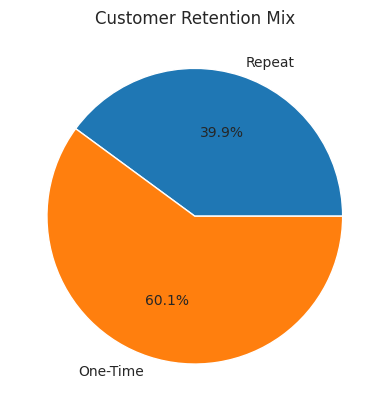

In [13]:
# Repeat VS One-Time Buyers

orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat = (orders > 1).sum()
one_time = (orders == 1).sum()

plt.figure()
plt.pie([repeat, one_time], labels = ['Repeat','One-Time'], autopct = '%1.1f%%')
plt.title("Customer Retention Mix")
plt.show()



---

## Recency-Frequency-Monetary (RFM) Analysis:

In [14]:
# RFM Segmentation / RFM Analysis
# Identifies High-Frequency, High-Value Customers VS At-Risk Segments

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (df['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

In [15]:
rfm.describe(percentiles = [0.2, 0.4, 0.6, 0.8, 0.9])

,Recency,Frequency,Monetary
count,1418.000000,1418.000000,1418.000000
mean,25.055712,1.899154,592.027616
std,17.276950,2.040967,1051.688477
min,0.000000,1.000000,-1462.500000
20%,6.000000,1.000000,172.216000
40%,17.000000,1.000000,294.516000
50%,25.000000,1.000000,331.380000
60%,31.000000,1.000000,408.900000
80%,44.000000,2.000000,711.744000
90%,51.000000,3.000000,1129.710000


In [16]:
import plotly.express as px

fig = px.scatter_3d(rfm,
                    x = 'Frequency',
                    y = 'Recency',
                    z = 'Monetary',
                    color = 'Monetary', # Color points by Monetary value (can be negative to show distinctions)
                    size = rfm['Monetary'].abs(), # Use absolute value for size to avoid negative values
                    hover_name = rfm.index, # Show CustomerID on hover
                    hover_data = {'Recency': True, 'Frequency': True, 'Monetary': True},
                    title = 'RFM Segmentation')

fig.update_layout(
    scene = dict(
        xaxis_title = 'Recency',
        yaxis_title = 'Frequency',
        zaxis_title = 'Monetary'
    ),
    width = 900,
    height = 800
)

fig.show()

* Based on the RFM Analysis: It appears that *most* customers are mid-spenders: They buy moderately frequently and last did so within the last week, and in total generate average (~$600) to below-average revenue for the business.



---

## Market Basket Analysis

In [17]:
!pip install mlxtend

### Data Preparation for Market Basket Analysis

To perform Market Basket Analysis, we need to transform our transactional data (`df`) into a format suitable for the Apriori algorithm. This involves creating a one-hot encoded representation where each row is an `InvoiceNo` (transaction) and each column is a `StockCode` (item). A `1` indicates the item was present in the transaction, and `0` otherwise.

Since Market Basket Analysis can be computationally intensive, especially with a large number of unique items, we'll focus on the most frequent items for efficiency and clearer insights.

In [18]:
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

# Grouping Transactions by InvoiceNo and StockCode
# Creating a List of items for each Transaction
basket = df.groupby(['InvoiceNo', 'StockCode'])['Quantity'].sum().unstack().reset_index().fillna(0).set_index('InvoiceNo')

# Converting Quantities to a Binary Format (1 if item Present, 0 Otherwise)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.applymap(encode_units)

# Filtering Out Transactions with no Items (if any, although unlikely after Cleaning)
basket_sets = basket_sets[(basket_sets > 0).sum(axis = 1) >= 1]

print(f"Shape of One-Hot Encoded Basket: {basket_sets.shape}")
display(basket_sets.head())

Shape of One-Hot Encoded Basket: (2294, 2330)


StockCode  100020  101200  101230  101240  101250  101330  101350  110010  \
InvoiceNo                                                                   
546890          0       0       0       0       0       0       0       0   
546898          0       0       0       0       0       0       0       0   
546899          0       0       0       0       0       0       0       0   
546900          0       0       0       0       0       0       0       0   
546902          0       0       0       0       0       0       0       0   

StockCode  150300  150340  150360  150390  150440  150560  150580  150600  \
InvoiceNo                                                                   
546890          0       0       0       0       0       0       0       0   
546898          0       0       0       0       0       0       0       0   
546899          0       0       0       0       0       0       0       0   
546900          0       0       0       0       0       0       0       0   
546902          0       0       0       0       0       0       0       0   

StockCode  160080  160100  160110  160120  160140  160150  160160  160200  \
InvoiceNo                                                                   
546890          0       0       0       0       0       0       0       0   
546898          0       0       0       0       0       0       0       0   
546899          0       0       0       0       0       0       0       0   
546900          0       0       0       0       0       0       0       0   
546902          0       0       0       0       0       0       0       0   

StockCode  160450  160460  160480  160490  160520  161510  161560  161610  \
InvoiceNo                                                                   
546890          0       0       0       0       0       0       0       0   
546898          0       0       0       0       0       0       0       0   
546899          0       0       0       0       0       0       0       0   
546900          0       0       0       0       0       0       0       0   
546902          0       0       0       0       0       0       0       0   

StockCode  161680  161690  162020  162160  162180  162190  162250  162350  \
InvoiceNo                                                                   
546890          0       0       0       0       0       0       0       0   
546898          0       0       0       0       0       0       0       0   
546899          0       0       0       0       0       0       0       0   
546900          0       0       0       0       0       0       0       0   
546902          0       0       0       0       0       0       0       0   

StockCode  162360  162370  162380  162440  162580  162590  170030  170110  \
InvoiceNo                                                                   
546890          0       0       0       0       0       0       0       0   
546898          0       0       0       0       0       0       0       0   
546899          0       0       0       0       0       0       0       0   
546900          0       0       0       0       0       0       0       0   
546902          0       0       0       0       0       0       0       0   

StockCode  170120  170130  170140  170210  170380  170840  170900  170910  \
InvoiceNo                                                                   
546890          0       0       0       0       0       0       0       0   
546898          0       0       0       0       0       0       0       0   
546899          0       0       0       0       0       0       0       0   
546900          0       0       0       0       0       0       0       0   
546902          0       0       0       0       0       0       0       0   

StockCode  170960  171070  171090  171290  171360  180070  180940  180970  \
InvoiceNo                                                                   
546890          0       0       0       0       0       0       0 

### Generating Frequent Itemsets using Apriori

Next, we'll use the Apriori algorithm to identify frequent itemsets, which are collections of items that often appear together in transactions. We'll set a minimum support threshold to focus on itemsets that occur with a certain frequency across all transactions. A higher support threshold will yield fewer, but stronger, itemsets, which is useful for practical business applications.

In [19]:
# Generating Frequent Itemsets with a Minimum Support of 0.01 (1%)
frequent_itemsets = apriori(basket_sets, min_support = 0.01, use_colnames = True)

# Support: How Popular an Itemset is. Measured by the Proportion of Transactions in which an Itemset appears.

print(f"Number of Frequent Itemsets found: {len(frequent_itemsets)}")
display(frequent_itemsets.sort_values(by = 'support', ascending = False).head(7))

Number of Frequent Itemsets found: 1501


,support,itemsets
529,0.150392,(475660)
600,0.143854,(851230)
269,0.128596,(224230)
599,0.109852,(850990)
582,0.092851,(848790)
198,0.091979,(220840)
457,0.085440,(229930)


### Generating Association Rules

Now that we have the frequent itemsets, we can generate association rules. These rules tell us about the relationships between items. We'll use metrics like 'Confidence' and 'Lift' to evaluate the strength and interestingness of these rules.

*   **Support**: The popularity of an itemset. It's the proportion of transactions that contain the itemset.
*   **Confidence**: Indicates how likely item Y is purchased when item X is purchased. It's the probability of finding Y in a transaction given that X is already in the transaction.
*   **Lift**: Indicates how much more likely item Y is purchased when item X is purchased, relative to its typical purchase rate. A lift value greater than 1 suggests a positive correlation between items X and Y; a value less than 1 suggests a negative correlation, and a value of 1 suggests no correlation.

In [20]:
# Generating Association Rules from the Frequent Itemsets
# We'll set a Minimum Confidence of 0.5 (50%)
rules = association_rules(frequent_itemsets, metric = "lift", min_threshold = 1.5)

print(f"Number of association rules found: {len(rules)}")
display(rules.sort_values(by = 'lift', ascending = False).head())

Number of association rules found: 3466


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1003,(231700),(231710),0.011770,0.010898,0.010026,0.851852,78.165926,1.0,0.009898,6.676439,0.998964,0.793103,0.850220,0.885926
1002,(231710),(231700),0.010898,0.011770,0.010026,0.920000,78.165926,1.0,0.009898,12.352877,0.998084,0.793103,0.919047,0.885926
659,(223010),(223000),0.015257,0.011770,0.011334,0.742857,63.115344,1.0,0.011154,3.843117,0.999404,0.722222,0.739795,0.852910
658,(223000),(223010),0.011770,0.015257,0.011334,0.962963,63.115344,1.0,0.011154,26.588056,0.995877,0.722222,0.962389,0.852910
912,(227450),(227480),0.013514,0.013078,0.010462,0.774194,59.200000,1.0,0.010285,4.370656,0.996575,0.648649,0.771201,0.787097


### Visualizing Association Rules for Business Intelligence

Visualizing these rules can help us quickly identify strong relationships and potential cross-selling opportunities. We'll create scatter plots to show the relationship between Support, Confidence, and Lift.

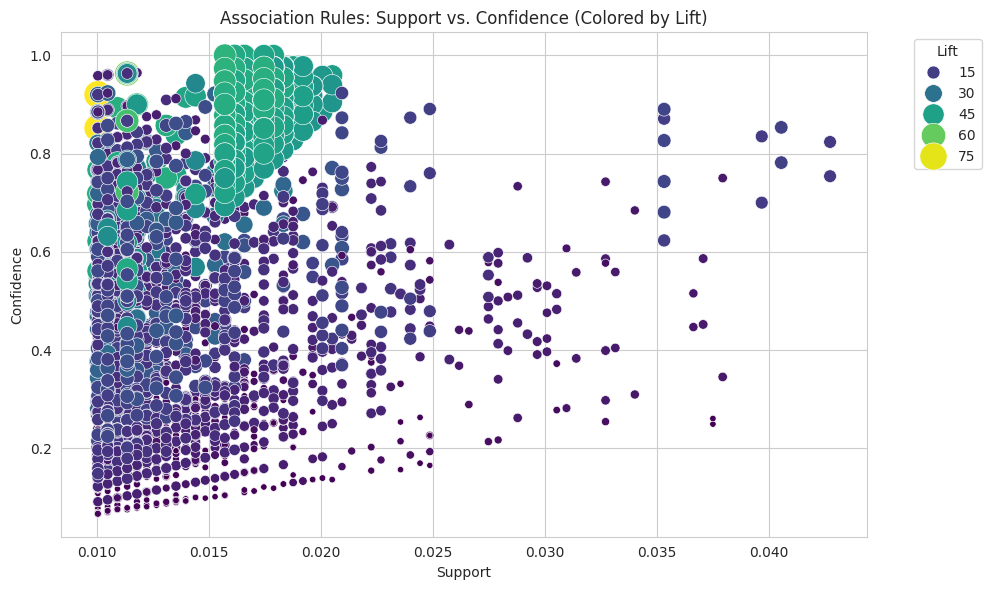

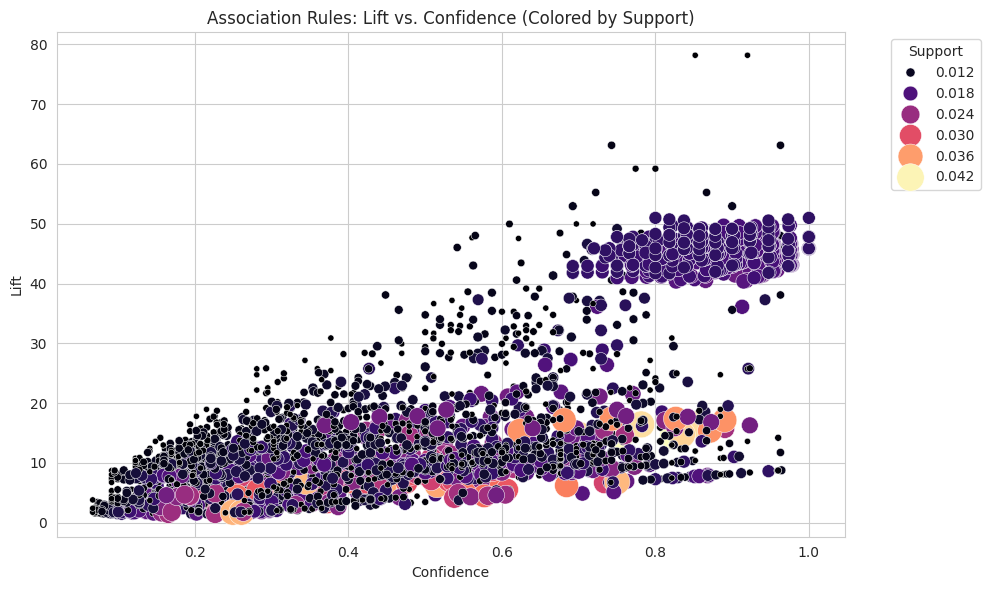

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of Confidence vs. Support
plt.figure(figsize = (10, 6))
sns.scatterplot(x = "support", y = "confidence", data = rules, hue = "lift", size = "lift", sizes = (20, 400), palette = "viridis")
plt.title('Association Rules: Support vs. Confidence (Colored by Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True)
plt.legend(title = 'Lift', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

# Scatter plot of Lift vs. Confidence
plt.figure(figsize = (10, 6))
sns.scatterplot(x = "confidence", y = "lift", data = rules, hue = "support", size = "support", sizes = (20, 400), palette = "magma")
plt.title('Association Rules: Lift vs. Confidence (Colored by Support)')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.grid(True)
plt.legend(title = 'Support', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

### Key Insights from Market Basket Analysis:

*   **High Lift, High Confidence Rules**: Look for points in the upper-right quadrant of the plots, especially those with bright colors (indicating high lift). These rules suggest strong, mutually beneficial relationships between products. For example, if 'Product A' and 'Product B' have high lift and confidence, customers buying 'A' are much more likely to buy 'B' than random chance suggests.

*   **Actionable Recommendations**:
    *   **Product Placement**: Place highly associated items near each other in the store or on the website.
    *   **Bundling/Promotions**: Create product bundles or offer discounts when associated items are purchased together.
    *   **Recommendation Systems**: Implement recommendation engines that suggest associated items to customers.
    *   **Inventory Management**: Ensure sufficient stock of items that are frequently bought together.

This analysis provides a data-driven approach to understanding customer purchasing behavior, leading to optimized marketing strategies and improved sales.